In [1]:
%load_ext autoreload
%autoreload 2

import sys
import pandas
sys.path.append("..")
#import pandas
import numpy as np
import matplotlib.pyplot as plt
import warnings
from numpy import random
warnings.filterwarnings('ignore')
import os
from pathlib import Path
from scipy.optimize import curve_fit
plotsdir = '/Users/billiemeadowcroft/Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures_2026/Fig_Dome/Plots/'
#dataout  = '/nfs/scistore15/saricgrp/bmeadowc/Scratch/Collagen/model_strict_tetramer/EquilibriumSeededWorkflow/Plotting/'

import sys

# Check the current recursion limit
current_limit = sys.getrecursionlimit()
print("Current recursion limit:", current_limit)

# Increase the recursion limit
sys.setrecursionlimit(6000)

Current recursion limit: 3000


In [2]:
clrs00 = ['#A10035','#2A0944','lightsalmon','#3FA796','#FEC260','pink','#A10035','#2A0944','#3FA796']
cmap0 = plt.cm.get_cmap('Spectral_r') #YlOrBr
cmap1 = plt.cm.get_cmap('YlOrBr') #YlOrBr
#cmap2 = plt.cm.get_cmap('twilight') #twilight
cmap2 = plt.cm.get_cmap('GnBu') #twilight
cmap3 = plt.cm.get_cmap('BuPu') #twilight
clrs = ['#a6611a','#dfc27d','#80cdc1','#018571','#f5f5f5']
clrs2 = ['#ffffcc','#c7e9b4','#7fcdbb','#41b6c4','#1d91c0','#225ea8','#0c2c84','lightsalmon']
clrs3 = ['#c7e9b4','#7fcdbb','#1d91c0','#225ea8','#0c2c84']
clrs = ['#a6611a','#dfc27d','olive','#80cdc1','#018571','steelblue','slateblue','#0c2c84','lightsalmon']
ClrsRiciChosenHalf = ["#7883acff","#73457aff","#b25268ff","#d49995ff"]


In [3]:
### ---------- Original Data --------- ###
TLifeDenseControl = [1099864214.852721, 647244015.958075, 302691299.9283709, 193380543.86555687, 125399124.23642237, 72382977.98185535, 54627694.158685945]
TLifeDenseControlSTD = [44699278.24732293,  22813613.258780956,  16283695.86598525, 10284609.004496682, 5920680.203341648, 7337765.993784864, 1091191.1142829212]
Taus_Av=[16401.45832306 , 10454.5752332   ,4405.37357503 , 3018.91964483,  2236.18922721 , 1977.03609215 , 1452.91837506]
Taus_Std=[604.8449615   , 49.68744122 , 935.75454548 , 288.93094047 , 414.79754408 , 340.46029844,  677.22418629]

### ---------- Dome Data --------- ###
TlifeDomeSTD = np.divide([191184179.20658043, 516847632.13053596, 33002953.407984972, 23590243.39952457, 5839307.490375702, 1409831.3360827242],10) #, 1449709.8551425608]
TlifeDome = np.divide([3895387776.415806, 1490984039.0871267, 749758994.7527883, 385176820.20860887, 81341300.00684947, 41799583.3318159],10) #, 18689795.66494985]
Tau_Dome = np.divide([148116.1925427, 68235.87589888, 30723.74236422, 26808.96695292, 18514.41350257, 15686.35297297],10)
Tau_Dome_STD = np.divide([49943.53425274, 10017.08163037, 3746.40370583, 3698.28181342, 2568.4389538, 988.80495353],10)


1.4558827094294902e-05
3.467758505373821e-05


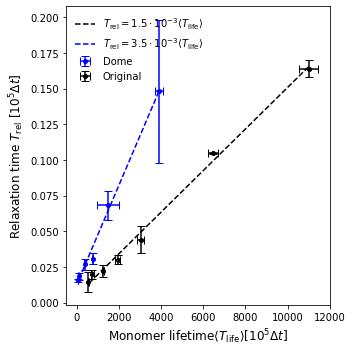

In [ ]:
fig,ax = plt.subplots(1,figsize = (5.,5))

ax.errorbar(np.divide(TlifeDome,10**5),np.divide(Tau_Dome,10**5),xerr = np.divide(TlifeDomeSTD,10**5), yerr = np.divide(Tau_Dome_STD,10**5), color = 'blue',linestyle = '',marker = 'o',markersize = 4,capsize = 4,label = "Dome")
ax.errorbar(np.divide(TLifeDenseControl,10**5),np.divide(Taus_Av,10**5),yerr = np.divide(Taus_Std,10**5), xerr = np.divide(TLifeDenseControlSTD,10**5), color = 'black',linestyle = '',marker = 'o',markersize = 4,capsize = 4,label = "Original")
x1,y1 = np.array(np.divide(TLifeDenseControl,10**5)),np.array(np.divide(Taus_Av,10**5))
m1,b1 = np.polyfit(x1,y1,1)
x11 = x1.reshape(-1,1)
a1,_,_,_ = np.linalg.lstsq(x11, y1)
print(m1)
ax.plot(x1,np.divide(m1*x1+b1,1),color = 'black',linestyle = '--',label = r'$T_{\mathrm{rel}} = 1.5\cdot 10^{-3}\langle T_{\mathrm{life}}\rangle$')
#ax.set_xlim(0.0,4000)
x1,y1 = np.array(np.divide(TlifeDome,10**5)),np.array(np.divide(Tau_Dome,10**5))
m1,b1 = np.polyfit(x1,y1,1)
x11 = x1.reshape(-1,1)
a1,_,_,_ = np.linalg.lstsq(x11, y1)
print(m1)
ax.plot(x1,np.divide(m1*x1+b1,1),color = 'blue',linestyle = '--',label = r'$T_{\mathrm{rel}} = 3.5\cdot 10^{-3}\langle T_{\mathrm{life}}\rangle$')
ax.set_xlabel(r'Monomer lifetime$\langle T_{\mathrm{life}}\rangle [10^5\Delta t]$',fontsize = 12)
ax.set_ylabel(r"Relaxation time $T_{\mathrm{rel}}$ [$10^5\Delta t$]",fontsize = 12)
#ax.set_yscale('log')
#ax.set_xscale('log')
#ax.set_ylim(0,0.2)
ax.legend(frameon = False,loc = 'upper left')
fig.tight_layout()
fig.savefig(plotsdir + 'MasterTlife_Trel_DOME.png',dpi = 1000)
